In [27]:
!pip install google-cloud-bigquery pandas matplotlib seaborn --quiet

Autenticação no Google Cloud

In [28]:
from google.colab import auth
auth.authenticate_user()

Importar bibliotecas

In [29]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from google.cloud import bigquery

import multiprocessing
import numpy as np

client = bigquery.Client()

In [30]:
project_id = "fiap1101"

client = bigquery.Client(project=project_id)

Corridas por dia da semana (2017)

In [31]:
query = """
SELECT
  CASE EXTRACT(DAYOFWEEK FROM pickup_datetime)
    WHEN 1 THEN 'Domingo'
    WHEN 2 THEN 'Segunda'
    WHEN 3 THEN 'Terça'
    WHEN 4 THEN 'Quarta'
    WHEN 5 THEN 'Quinta'
    WHEN 6 THEN 'Sexta'
    WHEN 7 THEN 'Sábado'
  END AS dia_semana,
  COUNT(*) AS total_corridas
FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2017`
GROUP BY dia_semana
"""

df = client.query(query).to_dataframe()
df

,dia_semana,total_corridas
0,Sábado,16878787
1,Segunda,14597337
2,Sexta,17388232
3,Terça,15824822
4,Quinta,17070436
5,Quarta,16744059
6,Domingo,14996643


Gráfico corridas por dia da semana

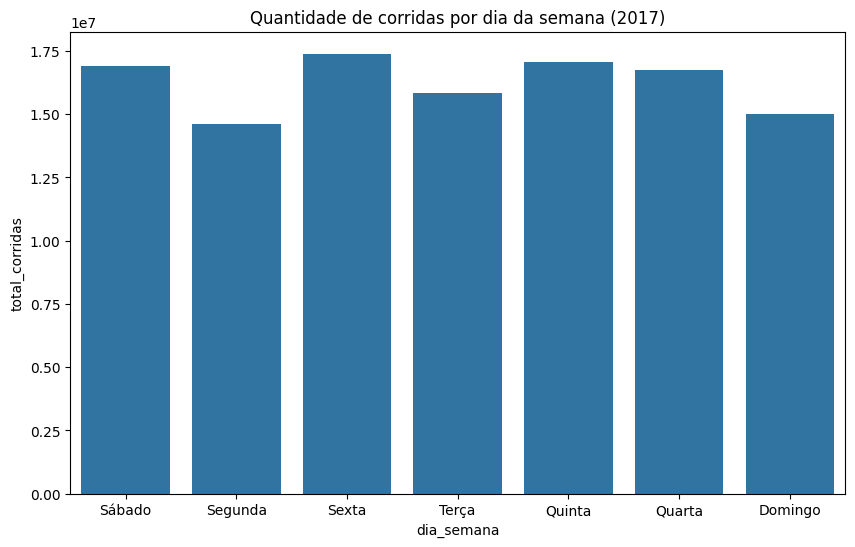

In [32]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x="dia_semana",y="total_corridas")
plt.title("Quantidade de corridas por dia da semana (2017)")
plt.show()

Valor das corridas por dia da semana

In [33]:
query = """
SELECT
  CASE EXTRACT(DAYOFWEEK FROM pickup_datetime)
    WHEN 1 THEN 'Domingo'
    WHEN 2 THEN 'Segunda'
    WHEN 3 THEN 'Terça'
    WHEN 4 THEN 'Quarta'
    WHEN 5 THEN 'Quinta'
    WHEN 6 THEN 'Sexta'
    WHEN 7 THEN 'Sábado'
  END AS dia_semana,
  AVG(total_amount) AS valor_medio
FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2017`
GROUP BY dia_semana
"""

df = client.query(query).to_dataframe()
df

,dia_semana,valor_medio
0,Quarta,16.652099956
1,Quinta,16.864819338
2,Terça,16.338582783
3,Sábado,15.259604652
4,Segunda,16.476886732
5,Sexta,16.542595752
6,Domingo,16.263421670


Gráfico valor médio por dia

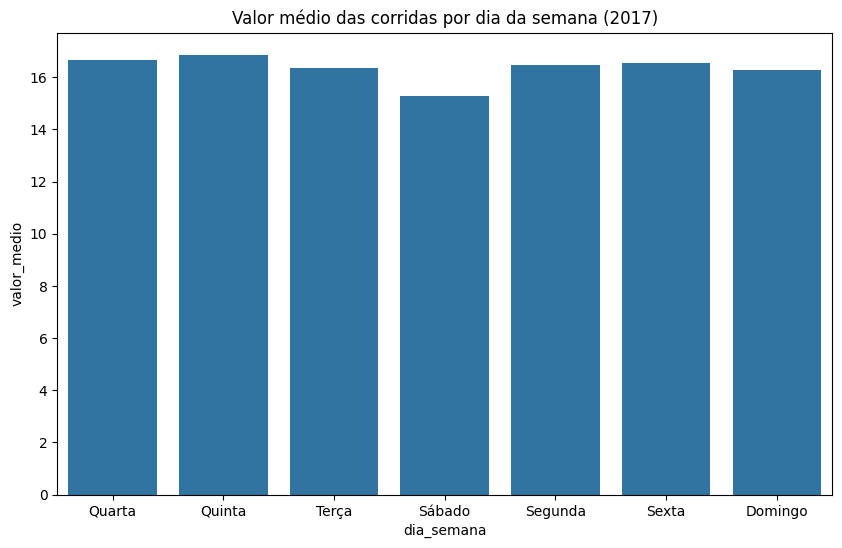

In [34]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x="dia_semana",y="valor_medio")
plt.title("Valor médio das corridas por dia da semana (2017)")
plt.show()

Valor por quantidade de passageiros

In [35]:
query = """
SELECT
  passenger_count,
  AVG(total_amount) AS valor_medio
FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2017`
WHERE passenger_count  BETWEEN 1 AND 9
GROUP BY passenger_count
ORDER BY passenger_count
"""

df = client.query(query).to_dataframe()
df

,passenger_count,valor_medio
0,1,16.158271793
1,2,17.037435018
2,3,16.842598621
3,4,16.879851839
4,5,16.355100141
5,6,16.257998678
6,7,51.014722222
7,8,53.501209440
8,9,66.185134228


Gráfico valor por passageiros

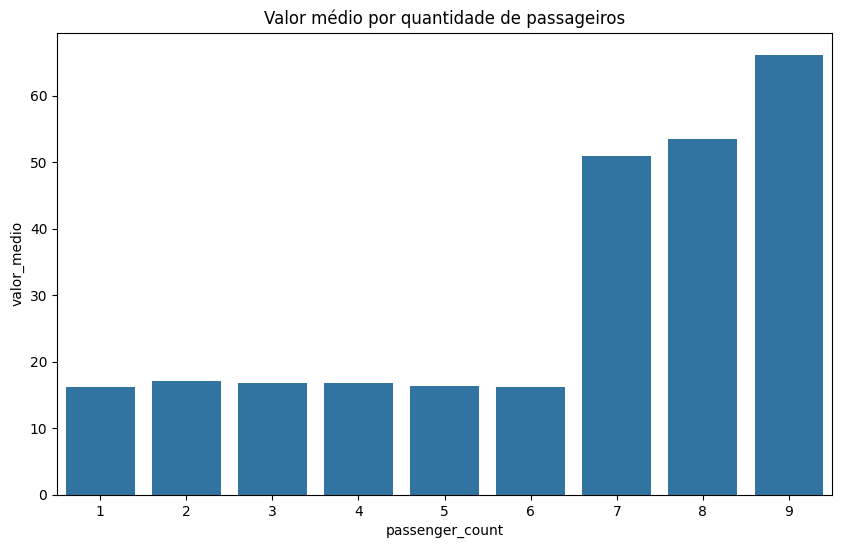

In [36]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x="passenger_count",y="valor_medio")
plt.title("Valor médio por quantidade de passageiros")
plt.show()

Gorjetas por dia da semana

In [37]:
query = """
SELECT
  CASE EXTRACT(DAYOFWEEK FROM pickup_datetime)
    WHEN 1 THEN 'Domingo'
    WHEN 2 THEN 'Segunda'
    WHEN 3 THEN 'Terça'
    WHEN 4 THEN 'Quarta'
    WHEN 5 THEN 'Quinta'
    WHEN 6 THEN 'Sexta'
    WHEN 7 THEN 'Sábado'
  END AS dia_semana,
  AVG(tip_amount) AS gorjeta_media
FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2017`
GROUP BY dia_semana
"""

df = client.query(query).to_dataframe()
df

,dia_semana,gorjeta_media
0,Quinta,1.952748274
1,Quarta,1.930869421
2,Sexta,1.864195780
3,Segunda,1.865871302
4,Sábado,1.613285398
5,Terça,1.880669559
6,Domingo,1.748779696


Gráfico gorjetas

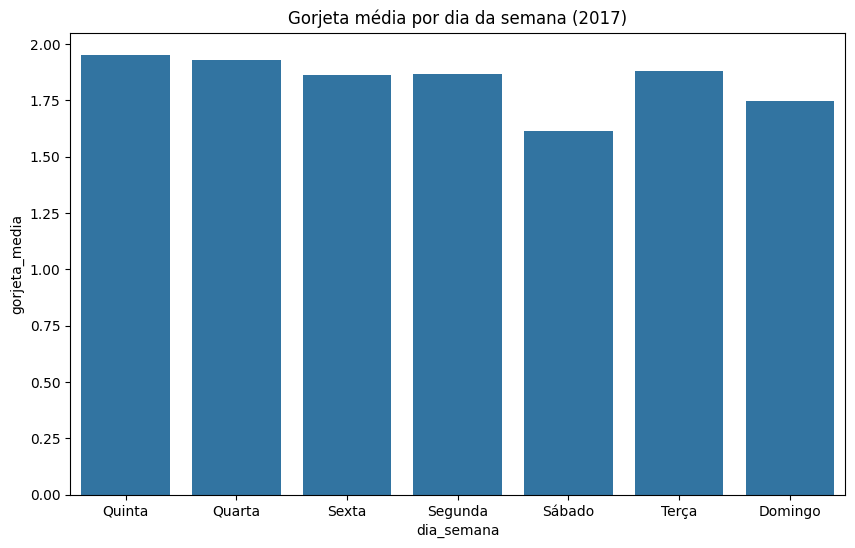

In [38]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x="dia_semana",y="gorjeta_media")
plt.title("Gorjeta média por dia da semana (2017)")
plt.show()

Evolução anual de corridas (2017–2021)

In [39]:
query = """
SELECT
  EXTRACT(YEAR FROM pickup_datetime) AS ano,
  COUNT(*) AS total_corridas
FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_*`
WHERE EXTRACT(YEAR FROM pickup_datetime) BETWEEN 2017 AND 2021
GROUP BY ano
ORDER BY ano
"""

df = client.query(query).to_dataframe()
df

,ano,total_corridas
0,2017,113500375
1,2018,102870513
2,2019,84597298
3,2020,24649255
4,2021,30903972


Gráfico evolução anual

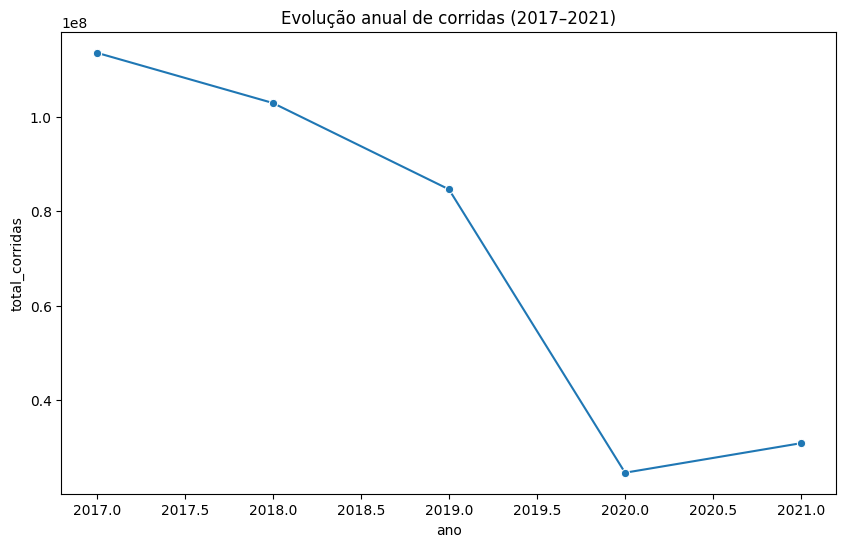

In [40]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df,x="ano",y="total_corridas",marker="o")
plt.title("Evolução anual de corridas (2017–2021)")
plt.show()

Total relativo por dia da semana

In [41]:
query = """
WITH base AS (

SELECT
  CASE EXTRACT(DAYOFWEEK FROM pickup_datetime)
    WHEN 1 THEN 'Domingo'
    WHEN 2 THEN 'Segunda'
    WHEN 3 THEN 'Terça'
    WHEN 4 THEN 'Quarta'
    WHEN 5 THEN 'Quinta'
    WHEN 6 THEN 'Sexta'
    WHEN 7 THEN 'Sábado'
  END AS dia_semana

FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_*`
WHERE _TABLE_SUFFIX BETWEEN '2017' AND '2021'
)

SELECT
  dia_semana,
  COUNT(*) total_corridas
FROM base
GROUP BY dia_semana
"""

df = client.query(query).to_dataframe()
df

,dia_semana,total_corridas
0,Quarta,53155528
1,Sábado,51730904
2,Domingo,44693208
3,Sexta,54863035
4,Segunda,46543470
5,Terça,51057331
6,Quinta,54480027


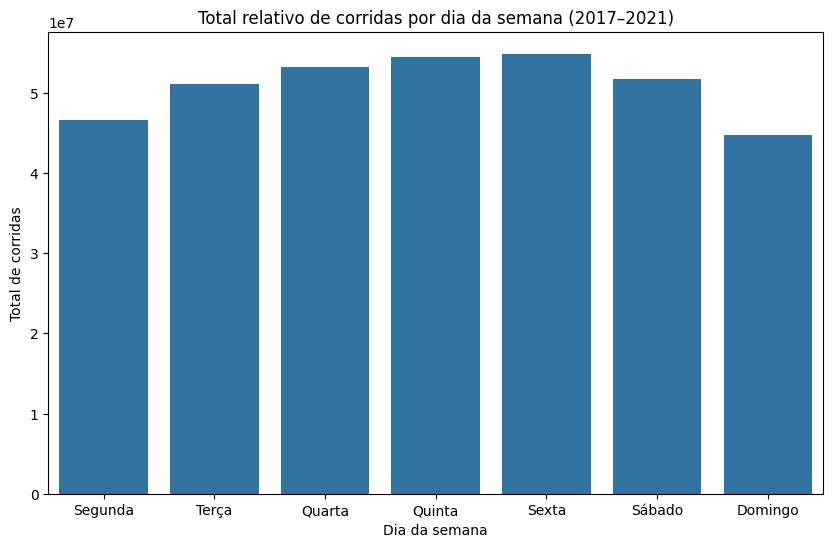

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="dia_semana",
    y="total_corridas",
    order=["Segunda","Terça","Quarta","Quinta","Sexta","Sábado","Domingo"]
)

plt.title("Total relativo de corridas por dia da semana (2017–2021)")
plt.xlabel("Dia da semana")
plt.ylabel("Total de corridas")

plt.show()

Total relativo por período do dia

In [43]:
query = """
WITH base AS (

SELECT
CASE
WHEN EXTRACT(HOUR FROM pickup_datetime) BETWEEN 0 AND 5 THEN 'Madrugada'
WHEN EXTRACT(HOUR FROM pickup_datetime) BETWEEN 6 AND 11 THEN 'Manhã'
WHEN EXTRACT(HOUR FROM pickup_datetime) BETWEEN 12 AND 17 THEN 'Tarde'
WHEN EXTRACT(HOUR FROM pickup_datetime) BETWEEN 18 AND 23 THEN 'Noite'
END AS periodo

FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_*`
WHERE _TABLE_SUFFIX BETWEEN '2017' AND '2021'
)

SELECT
periodo,
COUNT(*) total_corridas
FROM base
GROUP BY periodo
"""

df = client.query(query).to_dataframe()
df

,periodo,total_corridas
0,Tarde,117607763
1,Manhã,87853237
2,Noite,117200916
3,Madrugada,33861587


Gráfico período do dia

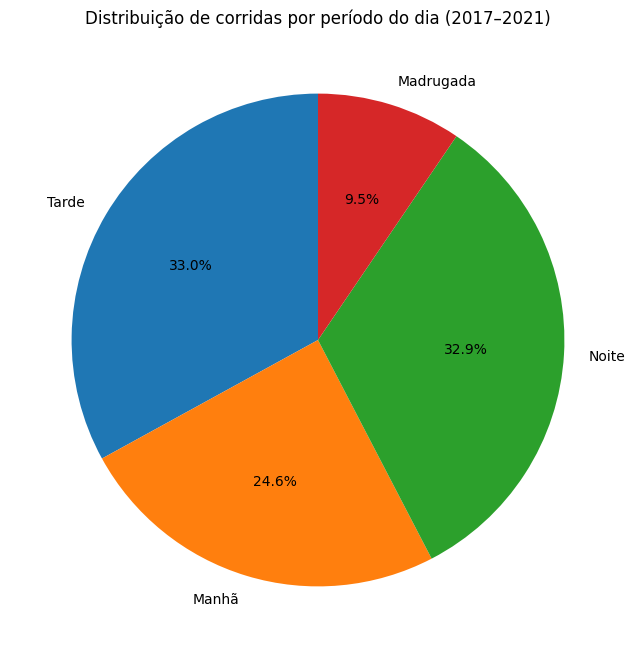

In [44]:
plt.figure(figsize=(8,8))

plt.pie(
    df["total_corridas"],
    labels=df["periodo"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribuição de corridas por período do dia (2017–2021)")

plt.show()

**Parte 2 - Uso de processamento de nuvem para criar modelos**

Carregar dados de 2021


In [45]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

# coloque aqui o ID do seu projeto
project_id = "fiap1101"

client = bigquery.Client(project=project_id)

print("Projeto ativo:", client.project)

Projeto ativo: fiap1101


In [46]:
query = """
SELECT
  passenger_count,
  trip_distance,
  fare_amount,
  tip_amount,
  total_amount
FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_*`
WHERE EXTRACT(YEAR FROM pickup_datetime) = 2021 AND passenger_count < 7 AND passenger_count > 0
LIMIT 5000000
"""

df_ml = client.query(query).to_dataframe()

df_ml.head()

,passenger_count,trip_distance,fare_amount,tip_amount,total_amount
0,1,0E-9,0E-9,0E-9,0E-9
1,1,0E-9,0E-9,0E-9,0E-9
2,1,0E-9,0E-9,0E-9,0E-9
3,1,0E-9,0E-9,0E-9,0E-9
4,1,0E-9,0E-9,0E-9,0E-9


<h1>Fazer pré-processamento em que os dados são separados em Treino/Teste (70/30) e que outliers ou dados incompletos são descartados.<h1>

Criar variável alvo

In [47]:
df_ml["tip_class"] = (df_ml["tip_amount"] > 0).astype(int)

Exploração inicial

In [48]:
df_ml.describe()

,passenger_count,tip_class
count,5000000.0,5.000000e+06
mean,1.473846,7.423304e-01
std,1.018345,4.373511e-01
min,1.0,0.000000e+00
25%,1.0,0.000000e+00
50%,1.0,1.000000e+00
75%,2.0,1.000000e+00
max,6.0,1.000000e+00


Histograma

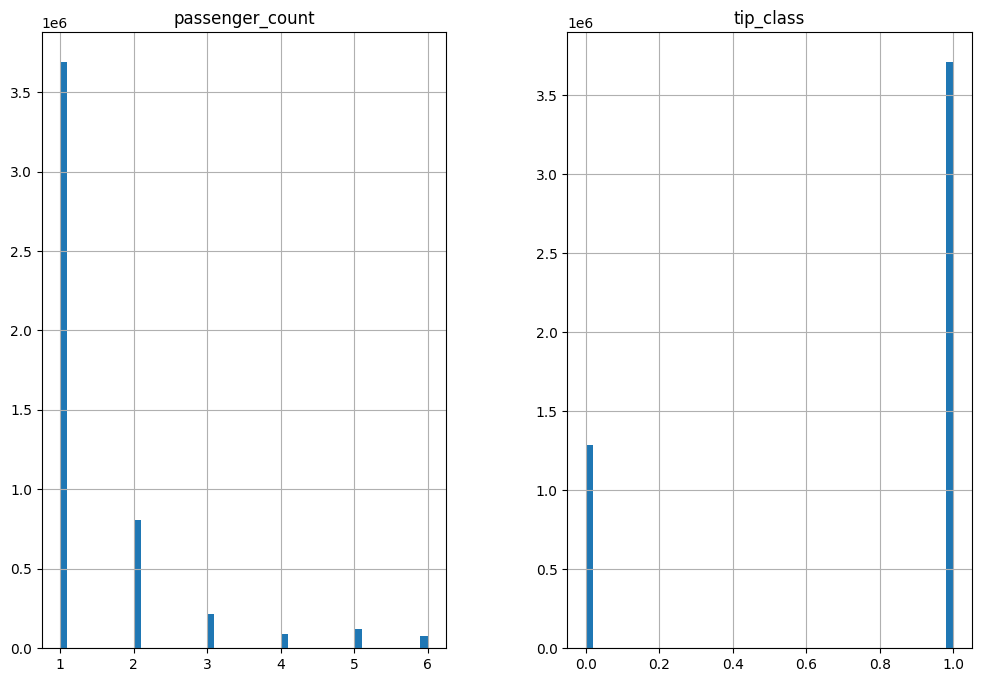

In [49]:
df_ml.hist(figsize=(12,8), bins=50)
plt.show()

Boxplot (detecção de outliers)

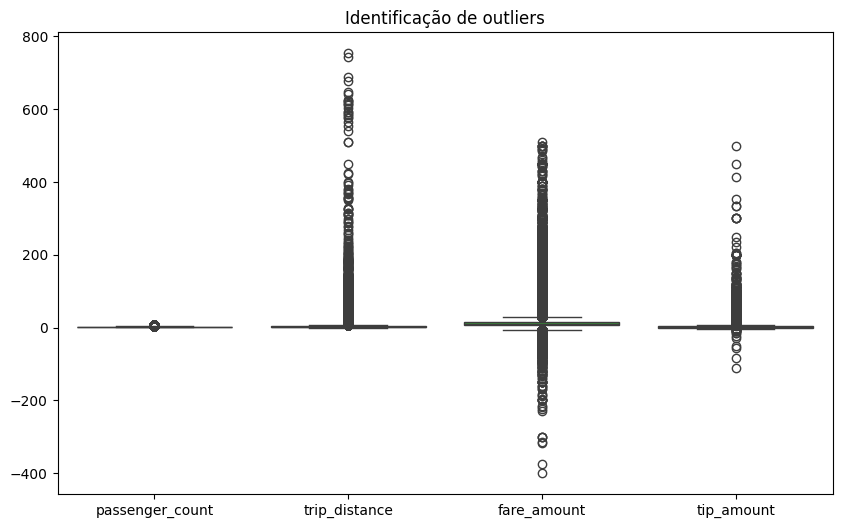

In [51]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df_ml[[
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "tip_amount"
]])

plt.title("Identificação de outliers")
plt.show()

Detectar outliers com IQR

In [53]:
df_ml = df_ml.astype({
    "passenger_count": "float",
    "trip_distance": "float",
    "fare_amount": "float",
    "tip_amount": "float",
    "total_amount": "float"
})

In [54]:
Q1 = df_ml.quantile(0.25)
Q3 = df_ml.quantile(0.75)

IQR = Q3 - Q1

Remover outliers

In [55]:
df_clean = df_ml[~(
    (df_ml < (Q1 - 1.5 * IQR)) |
    (df_ml > (Q3 + 1.5 * IQR))
).any(axis=1)]

Remover nulos

In [56]:
df_clean = df_clean.dropna()

<h1>Criar um modelo com o algoritmo e técnica de sua escolha, porém
TODOS os dados devem ser utilizados no treinamento</h1>

Selecionar variáveis

In [57]:
features = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "total_amount"
]

X = df_clean[features]
y = df_clean["tip_class"]

Split treino / teste

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

<h1>Utilizar qualquer estratégia de treinamento de distribuído</h1>

Modelo Random Forest (multiprocessing)

In [59]:
model = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    random_state=42
)

Treinar modelo

In [60]:
model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

Fazer previsões

In [61]:
pred = model.predict(X_test)

Avaliar modelo

In [62]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93    305966
           1       0.98      0.97      0.98    920695

    accuracy                           0.97   1226661
   macro avg       0.95      0.96      0.95   1226661
weighted avg       0.97      0.97      0.97   1226661



Importância das variáveis

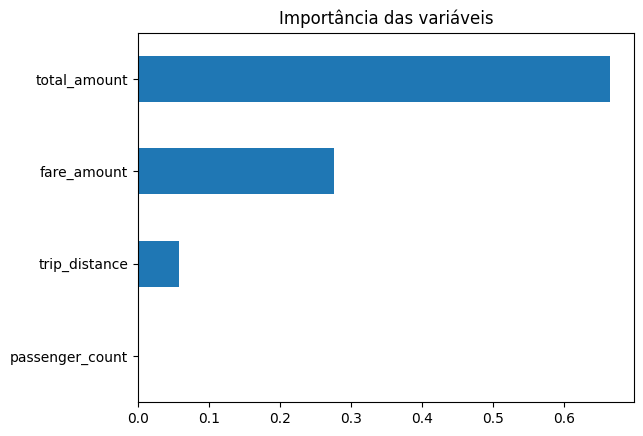

In [63]:
importances = model.feature_importances_

feat_importances = pd.Series(importances, index=features)

feat_importances.sort_values().plot(kind="barh")

plt.title("Importância das variáveis")
plt.show()